# Reproducible SageMath orbit enumeration

This notebook accompanies the manuscript *Matrix-valued polynomials and finite-field Hitchin systems: experiments with orbit counts and nilpotent fibres*.

It is intended to be run in a SageMath kernel.  The main parameters are `p`, `t`, and `d` in the first code cell.  The field is constructed as `GF(p)`, so changing `p` automatically changes the finite field used in the computation.  The direct orbit-enumeration cells are feasible only for the displayed parameter ranges; the formula-check cells at the end are much faster and are used for the formula-derived table columns in the paper.


In [3]:
%display latex
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Main parameters
# -----------------------------
d = -1  # Total degree of the bundle
t = 2   # Twist
p = 2   # Prime defining the field F_p
n = 2   # Rank; this notebook is written for rank 2

if not ZZ(p).is_prime():
    raise ValueError("This notebook is written for prime fields F_p; please choose p prime.")

q = p
FF = GF(p)  # Keep the finite field tied to p.

# Polynomial rings.  R is used only for the optional 'length' visualization;
# P is the finite-field polynomial ring used in the orbit computations.
R.<z> = PolynomialRing(RR)
P.<z> = PolynomialRing(FF)

MM_2_FF = MatrixSpace(FF, n, n)
Hasse_Weil_number = 2 * (t - 1) * sqrt(q)


In [4]:
#Generate the general linear group over Mat_2(F_p)
GLn = []

for g in MM_2_FF:
    if g.is_invertible() == True:
        GLn.append(g)

In [5]:
#Generate the space of MVP's over the finite field. Note the maximum degree ever needed is 2t+|d|
P_max = P.quotient(z^(2*t+abs(d)+1), "a")

MM = MatrixSpace(P_max,n,n)
MM

Full MatrixSpace of 2 by 2 dense matrices over Univariate Quotient Polynomial Ring in a over Finite Field of size 2 with modulus z^6

In [6]:
#Define a function which constructs all permissible pairs (d_1,d_2)
#based on stability conditons and the parameters d,t
def d_finder (d,t):
    d_pairs = []
    
    bound = abs(d)+t
    
    for i in range(-bound-1, bound+1):
        for j in range (-bound-1, bound+1):
            if i+j == d:
                if i-j <= t:
                    if i >= j: 
                        d_pairs.append([i,j])

    return d_pairs


In [7]:
#Define a function which artificially inverts a 2*2 MVP. This is done 
#manually instead of with sage's built in function as MVP's are not 
#invertible generally, however this can be done in our case by construction

def inv(m):
    
    m_11 = m[0,0]
    m_12 = m[0,1]
    m_21 = m[1,0]
    m_22 = m[1,1]
    
    invm = (1/(m_11*m_22-m_12*m_21))*MM(([m_22,-m_12],[-m_21,m_11]))
    
    return invm

In [8]:
#Define a function which takes in a list of MVPs and returns the list of lists
#where each entry is the list (matrix inverse, original matrix)
def conj_list(G):
    con_list = []
    
    for c in G:
        i = inv(c)
        con_list.append([i,c])
    
    return con_list


In [9]:
#Define a function which performs a computation of Burnside's lemma on the list
#of MVP's X subject to the Autmorphisms in the list G
def burnside(X,G):
    con_list = conj_list(G)
    
    fixed_points = 0
    
     
    for x in X:
        for g in con_list:
            #here is where the fixed point counting occures
            if g[0]*x*g[1] == x:
                fixed_points += 1 
    number_of_orbits = (1/len(con_list))*fixed_points
    
    return number_of_orbits



In [10]:
# This function is needed for showing specific orbits

def Orbit(x, G):
    Ox = []
    for g in G:
        # Conjugation action: g * x * g^-1
        res = g * x * g.inverse()
        # Keep track of unique elements in the orbit without using a set 
        # (avoids hash errors if 'res' is a mutable matrix)
        if res not in Ox:
            Ox.append(res)
    return Ox

In [11]:
#This function takes in the list of MVP's X, the automorphisms G and parameter t
#and returns a dictionary with keys given by (trace,det) pairs (i.e. by the fibers), and 
#values which are also dictionaries. The keys of which are "value" which is the number of 
#orbits in the fiber (trace,det) and "reps" a list of representatives of each orbit. 
def Char_poly_finder(X,G,t):
    
    Char_poly_dict = {}

    for tr in P.quotient(z^(t+1), "z"):
        for det in P.quotient(z^(2*t+1), "z"):
            Char_poly_dict[(tr,det)] = {"value":0,"reps":[]}
            
    con_list = conj_list(G)
    
    X_copy = list(X)
    used = []
    
    while X_copy != []:
        orb_rep = X_copy[0]
        orb_trace = orb_rep.trace()
        orb_det = orb_rep.determinant()
        
        Char_poly_dict[(orb_trace,orb_det)]["value"] += 1
        Char_poly_dict[(orb_trace,orb_det)]["reps"].append(orb_rep)
        
        for g in con_list:
            conj = g[0]*orb_rep*g[1]
            if conj in X_copy:
                X_copy.remove(conj)
                
    return Char_poly_dict



#This function takes in the list of MVP's X, the automorphisms G and parameter t
#and returns a dictionary with keys given by (trace,det) pairs (i.e. by the fibers), and 
#values which are also dictionaries. The keys of which are "value" which is the number of 
#orbits in the fiber (trace,det) and "reps" a list of representatives of each orbit. 
#########################################################################################################
## For some reason Char_poly_finder2 does not consider the case where there are x fibres with 0 orbits ##
#########################################################################################################
def Char_poly_finder2(X, G, t):
    def matrix_key(M):
        return tuple(M.list())  # Flattened for hashing

    Char_poly_dict = {}
    con_list = conj_list(G)

    X_dict = {matrix_key(M): M for M in X}

    while X_dict:
        key0, orb_rep = X_dict.popitem()

        trace = orb_rep.trace()
        det   = orb_rep.determinant()
        tr_det_key = (trace, det)

        if tr_det_key not in Char_poly_dict:
            Char_poly_dict[tr_det_key] = {"value": 0, "reps": []}

        Char_poly_dict[tr_det_key]["value"] += 1
        Char_poly_dict[tr_det_key]["reps"].append(orb_rep)

        # Remove all conjugates of orb_rep
        for inv_g, g in con_list:
            conj = inv_g * orb_rep * g
            key = matrix_key(conj)
            if key in X_dict:
                del X_dict[key]

    return Char_poly_dict

# Corrected fast version.  Unlike the earlier draft, this initializes every
# point of the Hitchin base, so fibres with zero orbits are retained and the
# histograms remain correct.
def Char_poly_finder_fast(X, G, t):
    def matrix_key(M):
        return tuple(M.list())

    Char_poly_dict = {}
    for tr in P.quotient(z^(t+1), "z"):
        for det in P.quotient(z^(2*t+1), "z"):
            Char_poly_dict[(tr, det)] = {"value": 0, "reps": []}

    con_list = conj_list(G)
    X_dict = {matrix_key(M): M for M in X}

    while X_dict:
        key0, orb_rep = X_dict.popitem()
        trace = orb_rep.trace()
        det = orb_rep.determinant()
        tr_det_key = (trace, det)

        Char_poly_dict[tr_det_key]["value"] += 1
        Char_poly_dict[tr_det_key]["reps"].append(orb_rep)

        for inv_g, g in con_list:
            conj = inv_g * orb_rep * g
            key = matrix_key(conj)
            if key in X_dict:
                del X_dict[key]

    return Char_poly_dict


In [12]:
# THIS IS THE MAIN COMPUTATION OF THIS PROGRAM

# The defaults below keep a fresh-kernel run manageable.  Setting these flags
# to True is useful for debugging very small examples, but can produce a large
# amount of output.
SHOW_AUTOMORPHISMS = False
SHOW_NILPOTENT_ORBITS = False
RUN_BURNSIDE_CHECK = True
USE_FAST_FIBRE_FINDER = True

# First we find the allowable (d_1,d_2) pairs.
d_pairs = d_finder(d, t)

# We generate a master dictionary which stores the collective data.
master_dict = {}
for tr in P.quotient(z^(t+1), "z"):
    for det in P.quotient(z^(2*t+1), "z"):
        master_dict[(tr, det)] = {"value": 0, "reps": []}

# Lists containing the same information separated by (d_1,d_2) pair.
dict_list = []
d_list = []

# Counters used to compare direct orbit counting with Burnside's lemma.
orbit_count = 0
burn_count = 0
matrix_list = []

for D in d_pairs:
    d_1, d_2 = D
    ell = d_1 - d_2
    print(f"Running stratum (d_1,d_2)=({d_1},{d_2}), ell={ell}, p={p}, t={t}")

    # Automorphism group.
    P_Aut = P.quotient(z^(ell+1), "z")
    if d_1 == d_2:
        Aut = list(GLn)
    else:
        Aut = []
        for a_11 in range(1, p):
            for a_22 in range(1, p):
                for a_12 in P_Aut:
                    Aut.append(MM(([a_11, a_12], [0, a_22])))

    pretty_print(LatexExpr(rf"|\mathbb{{G}}| = {len(Aut)}"))

    # Degree-constrained stable matrix-valued polynomials.
    poly_diag = P.quotient(z^(t+1), "z")
    poly_up = P.quotient(z^(ell+t+1), "z")
    poly_down = P.quotient(z^(t-ell+1), "z")

    Mat_t_V = []
    for a_11 in poly_diag:
        for a_22 in poly_diag:
            for a_12 in poly_up:
                for a_21 in poly_down:
                    # In rank two and odd total degree, stability is equivalent
                    # to the lower-left entry being nonzero.
                    if a_21 != 0:
                        Mat_t_V.append(MM(([a_11, a_12], [a_21, a_22])))

    pretty_print(LatexExpr(rf"|M^t_{{({d_1},{d_2})}}|^s = {len(Mat_t_V)}"))

    nilpotent_elements = [M for M in Mat_t_V if M.trace() == 0 and M.determinant() == 0]
    print("Number of stable elements in the nilpotent fibre:", len(nilpotent_elements))

    if SHOW_NILPOTENT_ORBITS:
        seen_elements = []
        for x in nilpotent_elements:
            if x in seen_elements:
                continue
            current_orbit = Orbit(x, Aut)
            print("Orbit for representative:")
            show(x)
            matrix_list.append(x)
            print("Contains elements:")
            show(current_orbit)
            for element in current_orbit:
                if element not in seen_elements:
                    seen_elements.append(element)

    if RUN_BURNSIDE_CHECK:
        burn = burnside(Mat_t_V, Aut)
        burn_count += burn
    else:
        burn = None

    if USE_FAST_FIBRE_FINDER:
        Char_dict = Char_poly_finder_fast(Mat_t_V, Aut, t)
    else:
        Char_dict = Char_poly_finder(Mat_t_V, Aut, t)

    # Update the master dictionary and the direct orbit count.
    for char in Char_dict:
        orbit_count += Char_dict[char]["value"]
        master_dict[char]["value"] += Char_dict[char]["value"]
        master_dict[char]["reps"].extend(Char_dict[char]["reps"])

    d_list.append(D)
    dict_list.append(Char_dict)

    print(D)
    pretty_print(LatexExpr(rf"|\mathbb{{G}}| = {len(Aut)}"))
    if SHOW_AUTOMORPHISMS:
        pretty_print("Elements of", LatexExpr(rf"\ \mathbb{{G}}"))
        for a in Aut:
            show(a)
            print()
    if burn is not None:
        print("Burnside orbit count:", burn)
    pretty_print(LatexExpr(rf"|M^t_{{({d_1},{d_2})}}|^s = {len(Mat_t_V)}"))

if RUN_BURNSIDE_CHECK:
    print("Total Burnside orbit count:", QQ(burn_count))
pretty_print(LatexExpr(rf"|\mathcal{{M}}^t_{{r,d}}| = {orbit_count}"))


Running stratum (d_1,d_2)=(0,-1), ell=1, p=2, t=2


|\mathbb{G}| = 4

|M^t_{(0,-1)}|^s = 3072

Number of stable elements in the nilpotent fibre: 12


[0, -1]


|\mathbb{G}| = 4

Burnside orbit count: 768


|M^t_{(0,-1)}|^s = 3072

Total Burnside orbit count: 768


|\mathcal{M}^t_{r,d}| = 768

In [13]:
#We now include additional information to the master dictionary namely 
#the "distance" the fiber is from 0 as computed using the integral
#from 0 to 1 of the sum of the squares of the trace and determinant 
for char in master_dict:
    A = R(char[0])
    B = R(char[1])
    
    f = (A)^2
    g = (B)^2
    h = f+g
    I = h.integral()
    I_1 = I(z = 1)
    I_2 = I(z = 0)
    I_final = I_1-I_2
    
    master_dict[char]["length"] = I_final

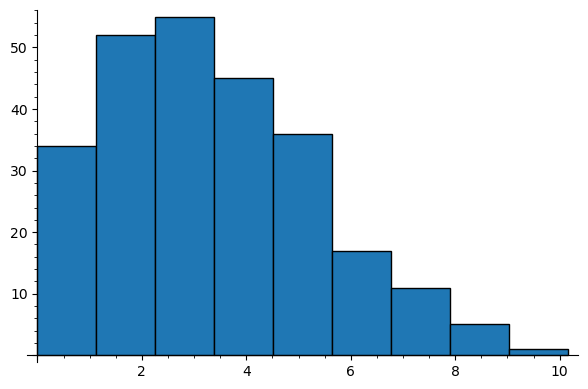

In [14]:
#Produce a histogram where the bins are separated by length and populated by fibers
length_list = []

for char in master_dict:
    length_list.append(master_dict[char]["length"])

histogram(length_list,bins = 9)

for (d_1,d_2) = [0, -1]
there are 4 fibers which contain 0 orbits
there are 24 fibers which contain 1 orbits
there are 60 fibers which contain 2 orbits
there are 80 fibers which contain 3 orbits
there are 60 fibers which contain 4 orbits
there are 24 fibers which contain 5 orbits
there are 4 fibers which contain 6 orbits


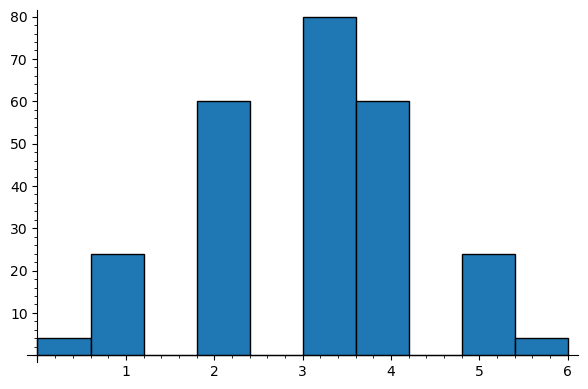

In [21]:
#Generate a histogram with the bins separated by number of orbits and populated by fiber.
#Note each diagram and data set is based only on a single (d_1,d_2) pair (listed at the top)
count = 0
for i in dict_list:
    print("for (d_1,d_2) = "+str(d_list[count]))
    count +=1
    count_dict = {}
    big = 0
    for fiber_key in i:
        if i[fiber_key]["value"] > big:
            big = i[fiber_key]["value"]

    for j in range (big+1):
        count_dict[j] = 0

    for char in i:
        count_dict[i[char]["value"]] += 1
    
    for c in count_dict:
        print ("there are "+str(count_dict[c])+" fibers which contain "+str(c)+" orbits")

    value_list = []

    for char in i:
        value_list.append(i[char]["value"])
    
    show(histogram(value_list))

In [0]:
#Generate a histogram with the bins separated by number of orbits and populated by fiber.
#This uses the total collected data, and is the sum of the histograms above
print ("In total ")
count_dict = {}
big = 0
for fiber_key in master_dict:
    if master_dict[fiber_key]["value"] > big:
        big = master_dict[fiber_key]["value"]

for i in range (big+1):
    count_dict[i] = 0

for char in master_dict:
    count_dict[master_dict[char]["value"]] += 1
    
for c in count_dict:
    print ("there are "+str(count_dict[c])+" fibers which contain "+str(c)+" orbits")
    
value_list = []

for char in master_dict:
    value_list.append(master_dict[char]["value"])

show(histogram(value_list))

for (d_1,d_2) = [0, -1]
there are 4 fibers which contain 0 orbits
there are 24 fibers which contain 1 orbits
there are 60 fibers which contain 2 orbits
there are 80 fibers which contain 3 orbits
there are 60 fibers which contain 4 orbits
there are 24 fibers which contain 5 orbits
there are 4 fibers which contain 6 orbits


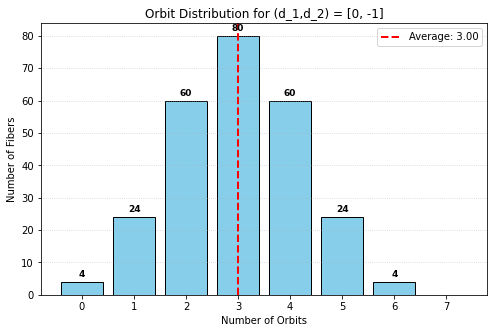

In [20]:
#####################################################################################
## This is just a new histogram to make them look prettier and more easier to read ##
#####################################################################################

# Generate a histogram with the bins separated by number of orbits and populated by fiber.
count = 0
for i in dict_list:
    print("for (d_1,d_2) = " + str(d_list[count]))
    count += 1
    count_dict = {}
    big = 0
    for fiber_key in i:
        if i[fiber_key]["value"] > big:
            big = i[fiber_key]["value"]

    for j in range(big + 1):
        count_dict[j] = 0

    for char in i:
        count_dict[i[char]["value"]] += 1
    
    for c in count_dict:
        print("there are " + str(count_dict[c]) + " fibers which contain " + str(c) + " orbits")

    value_list = []
    for char in i:
        value_list.append(i[char]["value"])
    
    # --- CALCULATE AVERAGE ---
    avg_value = float(np.mean(value_list)) if value_list else 0
    
    # --- UPDATED PLOTTING LOGIC WITH MATPLOTLIB ---
    # Create a clean Matplotlib figure
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Define exact bins up to max + 1
    custom_bins = list(range(0, big + 3)) 
    
    # Plot the histogram and capture the patch objects (the bars)
    counts, bins, patches = ax.hist(value_list, bins=custom_bins, align='left', 
                                    rwidth=0.8, color='skyblue', edgecolor='black')
    
    # 1. Show the number on top of every bar
    for patch in patches:
        height = patch.get_height()
        if height > 0: # Only label bars that actually have data
            ax.annotate(f'{int(height)}',
                        xy=(patch.get_x() + patch.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
            
    # 2. Highlight the average with a vertical line
    ax.axvline(avg_value, color='red', linestyle='--', linewidth=2, 
               label=f'Average: {avg_value:.2f}')
    
    # Formatting the chart
    ax.set_xlabel('Number of Orbits')
    ax.set_ylabel('Number of Fibers')
    ax.set_title(f'Orbit Distribution for (d_1,d_2) = {d_list[count-1]}')
    ax.set_xticks(range(0, big + 2)) # Ensure every integer tick is shown
    ax.legend()
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    # Display the plot
    plt.show()

In total 
there are 4 fibers which contain 0 orbits
there are 24 fibers which contain 1 orbits
there are 60 fibers which contain 2 orbits
there are 80 fibers which contain 3 orbits
there are 60 fibers which contain 4 orbits
there are 24 fibers which contain 5 orbits
there are 4 fibers which contain 6 orbits


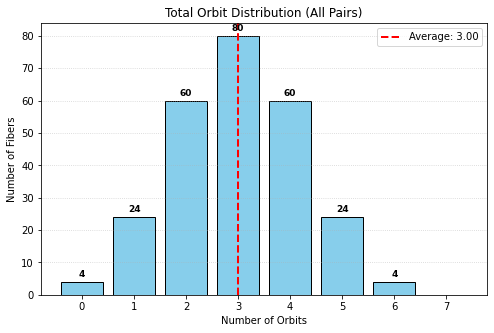

256


In [19]:
#####################################################################################
## This is just a new histogram to make them look prettier and more easier to read ##
#####################################################################################
# Generate a histogram with the bins separated by number of orbits and populated by fiber.
# This uses the total collected data, and is the sum of the histograms above
print("In total ")
count_dict = {}
big = 0
for fiber_key in master_dict:
    if master_dict[fiber_key]["value"] > big:
        big = master_dict[fiber_key]["value"]

for i in range(big + 1):
    count_dict[i] = 0

for char in master_dict:
    count_dict[master_dict[char]["value"]] += 1
Sum = 0    
for c in count_dict:
    print("there are " + str(count_dict[c]) + " fibers which contain " + str(c) + " orbits")
    Sum += int(str(count_dict[c]))
value_list = []
for char in master_dict:
    value_list.append(master_dict[char]["value"])

# --- CALCULATE AVERAGE ---
avg_value = float(np.mean(value_list)) if value_list else 0

# --- SECOND ALTERATION PLOTTING LOGIC (MATPLOTLIB) ---
# Create a clean Matplotlib figure
fig, ax = plt.subplots(figsize=(8, 5))

# Define exact bins up to max + 1
custom_bins = list(range(0, big + 3)) 

# Plot the histogram and capture the patch objects (the bars)
counts, bins, patches = ax.hist(value_list, bins=custom_bins, align='left', 
                                rwidth=0.8, color='skyblue', edgecolor='black')

# 1. Show the number on top of every bar
for patch in patches:
    height = patch.get_height()
    if height > 0:  # Only label bars that actually have data
        ax.annotate(f'{int(height)}',
                    xy=(patch.get_x() + patch.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
# 2. Highlight the average with a vertical line
ax.axvline(avg_value, color='red', linestyle='--', linewidth=2, 
           label=f'Average: {avg_value:.2f}')

# Formatting the chart
ax.set_xlabel('Number of Orbits')
ax.set_ylabel('Number of Fibers')
ax.set_title('Total Orbit Distribution (All Pairs)')
ax.set_xticks(range(0, big + 2))  # Ensure every integer tick is shown
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Display the plot
plt.show()
print(Sum)

## Optional exploratory cells

The cells below inspect the fibre dictionary produced by the main computation.  They are useful for small examples and for generating histograms, but they can produce a large amount of output.  They do not change the table formulas proved in the manuscript.

In [0]:
#Print all fibers and the number of orbits contained there in
for char in master_dict:
    print (char,"\n",master_dict[char]["value"],"\n")

In [0]:
#Print representatives of a particular fiber
for a in master_dict[(0,0)]["reps"]:
    print (a,"\n")

In [0]:
#Print the fibers with a specified number of orbits. 
Specified_Number_Of_Orbits = 6
count = 0
for char in master_dict:
    if master_dict[char]["value"] == Specified_Number_Of_Orbits:
        count +=1
        print (char,"\n",master_dict[char]["value"],"\n")
print(count)    

In [0]:
################################################################
## Calculating fibres inside the naive Hasse-Weil curve bound ##
################################################################
count = 0
for char in master_dict:
    N = master_dict[char]["value"]
    K = N- (q+1)
    if abs(K) <= Hasse_Weil_number: 
        count +=1
        #print (char,"\n",master_dict[char]["value"],"\n") 
        
print(count) 

In [0]:
################################################################
## Calculating the fibres outside the naive Hasse-Weil curve bound ##
################################################################
count = 0
for char in master_dict:
    N = master_dict[char]["value"]
    K = N- (q+1)
    if abs(K) > Hasse_Weil_number: 
        count +=1
        #print (char,"\n",master_dict[char]["value"],"\n")
        
print(count) 

In [0]:
#################################
## Finding the smallest fibres ##
#################################
min_val = min(item["value"] for item in master_dict.values())
count = 0
# Step 2: Print the fibers (keys) with the maximum value
for char in master_dict:
    if master_dict[char]["value"] == min_val:
        count +=1
        print(char, "\n", master_dict[char]["value"], "\n")
print(count) 

In [0]:
#################################
## Finding the largest fibres ##
#################################
max_val = max(item["value"] for item in master_dict.values())
count = 0
# Step 2: Print the fibers (keys) with the maximum value
for char in master_dict:
    if master_dict[char]["value"] == max_val:
        count += 1
        print(char, "\n", master_dict[char]["value"], "\n")
print(count)    

In [0]:
# Express test: ordinary nilpotent 2 x 2 matrices over a chosen finite field.
# This is not used in the manuscript tables; it is kept as a small sanity check.
test_p = 5
MM_2_test = MatrixSpace(GF(test_p), 2, 2)
Nil = []
for a in MM_2_test:
    if a[1, 0] != 0:
        if a.determinant() == 0 and a.trace() == 0:
            Nil.append(a)
print(len(Nil))

## Formula checks

The following cells implement the closed formulas proved in the paper.  They are much faster than direct enumeration and should be used for the stable-element, group-order, total-orbit, and average-fibre columns of the tables.



In [22]:
def stable_element_count(q, t, ell):
    return q^(3*t+3) * (q^(t+1) - q^ell)

def gauge_group_order(q, ell):
    return (q-1)^2 * q^(ell+1)

def stable_orbit_count(q, t, ell):
    return q^(3*t+2) * ((q^(t+1-ell)-1)//(q-1))

def hitchin_base_size(q, t):
    return q^(3*t+2)

def average_fibre_size(q, t, ell):
    return stable_orbit_count(q,t,ell)//hitchin_base_size(q,t)

for T in range(1,6):
    print("t=", T)
    for n in range((T-1)//2 + 1):
        ell = 2*n + 1
        print((n,-n-1), "stable elements", stable_element_count(p,T,ell),
              "|G|", gauge_group_order(p,ell),
              "orbits", stable_orbit_count(p,T,ell),
              "average", average_fibre_size(p,T,ell))


t= 1
(0, -1) stable elements 128 |G| 4 orbits 32 average 1
t= 2
(0, -1) stable elements 3072 |G| 4 orbits 768 average 3
t= 3
(0, -1) stable elements 57344 |G| 4 orbits 14336 average 7
(1, -2) stable elements 32768 |G| 16 orbits 2048 average 1
t= 4
(0, -1) stable elements 983040 |G| 4 orbits 245760 average 15
(1, -2) stable elements 786432 |G| 16 orbits 49152 average 3
t= 5
(0, -1) stable elements 16252928 |G| 4 orbits 4063232 average 31
(1, -2) stable elements 14680064 |G| 16 orbits 917504 average 7
(2, -3) stable elements 8388608 |G| 64 orbits 131072 average 1


## Reproducibility note

For manuscript submission, direct orbit enumeration should be rerun in SageMath for every histogram or nilpotent-fibre table being claimed as directly enumerated.  The formula-derived table columns are checked independently in the accompanying Python verification notebook.